In [25]:
import oracledb

host = "diana.lcc.uma.es"
port = "1521"
sid = "atenea"
user = "UBD2864"
password = "MasterBD2526"

connection = oracledb.connect(
    user=user,
    password=password,
    host=host, port = port, sid = sid)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\sergi\AppData\Local\Temp\ipykernel_8364\948313722.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sales_monthly = pd.read_sql(query_sales_monthly, con=connection)


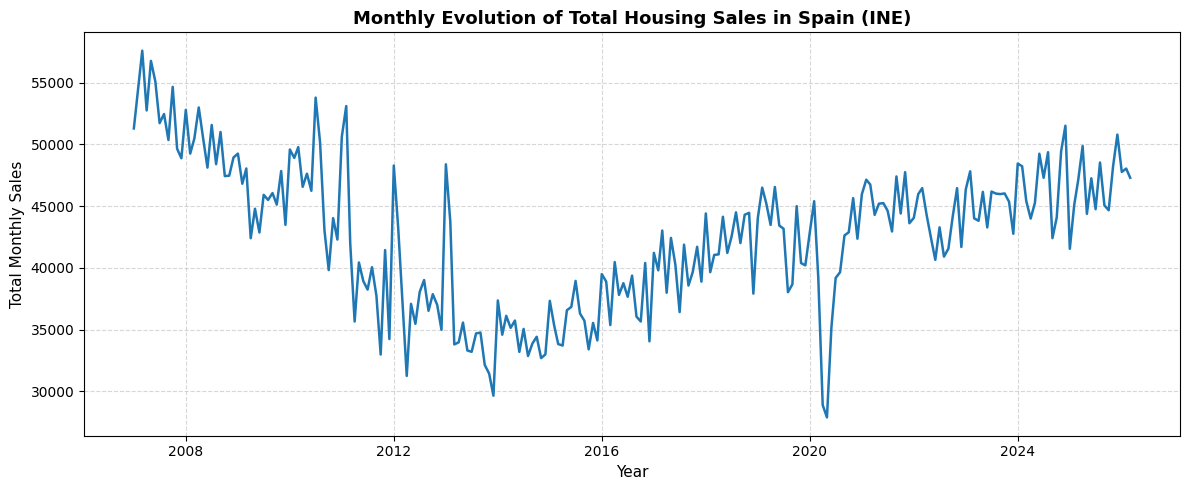

In [ ]:
query_sales_monthly = """
SELECT 
    m.YEAR,
    m.MONTH,
    SUM(s.TOTAL_SALES) AS TOTAL_SALES
FROM SALES s
JOIN MONTH m ON s.MONTH_IDMONTH = m.IDMONTH
GROUP BY m.YEAR, m.MONTH
ORDER BY m.YEAR ASC, m.MONTH ASC
"""

df_sales_monthly = pd.read_sql(query_sales_monthly, con=connection)

df_sales_monthly['DATE'] = pd.to_datetime(
    df_sales_monthly['YEAR'].astype(str) + '-' + df_sales_monthly['MONTH'].astype(str) + '-01'
)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_sales_monthly, 
    x='DATE', 
    y='TOTAL_SALES', 
    color='#1f77b4',
    linewidth=1.8
)

plt.title('Monthly Evolution of Total Housing Sales in Spain (INE)', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Total Monthly Sales', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('sales_monthly_total.png', dpi=300)
plt.show()

C:\Users\sergi\AppData\Local\Temp\ipykernel_8364\306707205.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_trans = pd.read_sql(query_transactions, con=connection)


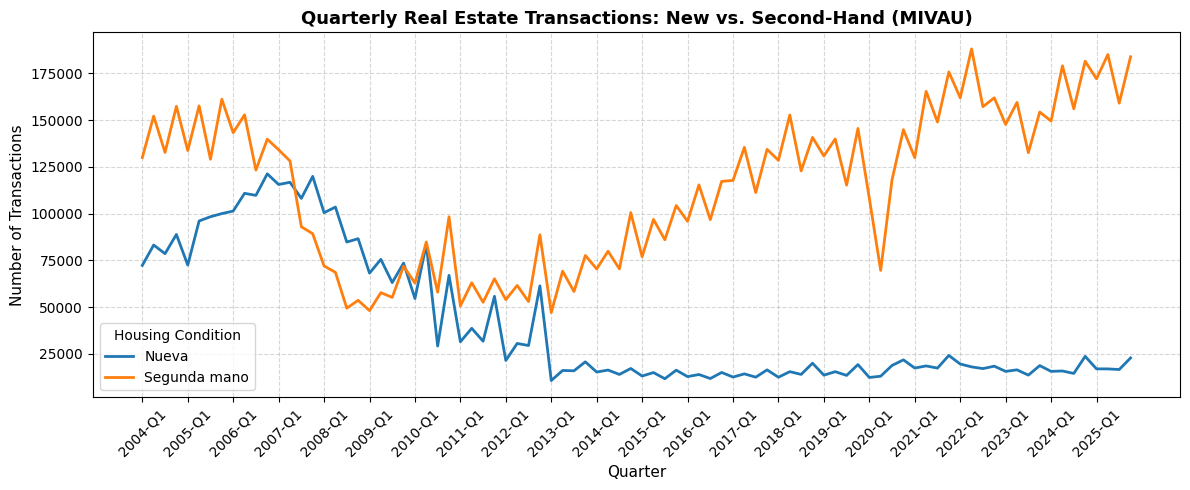

In [ ]:
query_transactions = """
SELECT 
    q.YEAR,
    q.QUARTER,
    c.CONDITION AS HOUSING_CONDITION,
    SUM(t.TOTAL_TRANSACTIONS) AS TOTAL_TRANSACTIONS,
    SUM(t.TOTAL_TRANSACTION_PRICE) AS TOTAL_AMOUNT
FROM TRANSACTIONS t
JOIN QUARTER q ON t.QUARTER_IDQUARTER = q.IDQUARTER
JOIN CONDITION c ON t.CONDITION_IDCONDITION = c.IDCONDITION
WHERE c.CONDITION != 'Sin especificar'
GROUP BY q.YEAR, q.QUARTER, c.CONDITION
ORDER BY q.YEAR ASC, q.QUARTER ASC
"""

df_trans = pd.read_sql(query_transactions, con=connection)

df_trans['PERIOD'] = df_trans['YEAR'].astype(str) + '-Q' + df_trans['QUARTER'].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_trans, 
    x='PERIOD', 
    y='TOTAL_TRANSACTIONS', 
    hue='HOUSING_CONDITION',
    linewidth=2
)

plt.xticks(ticks=range(0, len(df_trans['PERIOD'].unique()), 4), labels=df_trans['PERIOD'].unique()[::4], rotation=45)

plt.title('Quarterly Real Estate Transactions: New vs. Second-Hand (MIVAU)', fontsize=13, fontweight='bold')
plt.xlabel('Quarter', fontsize=11)
plt.ylabel('Number of Transactions', fontsize=11)
plt.legend(title='Housing Condition')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('transactions_condition_evolution.png', dpi=300)
plt.show()

C:\Users\sergi\AppData\Local\Temp\ipykernel_8364\3344549215.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_regime = pd.read_sql(query_transactions_regime, con=connection)


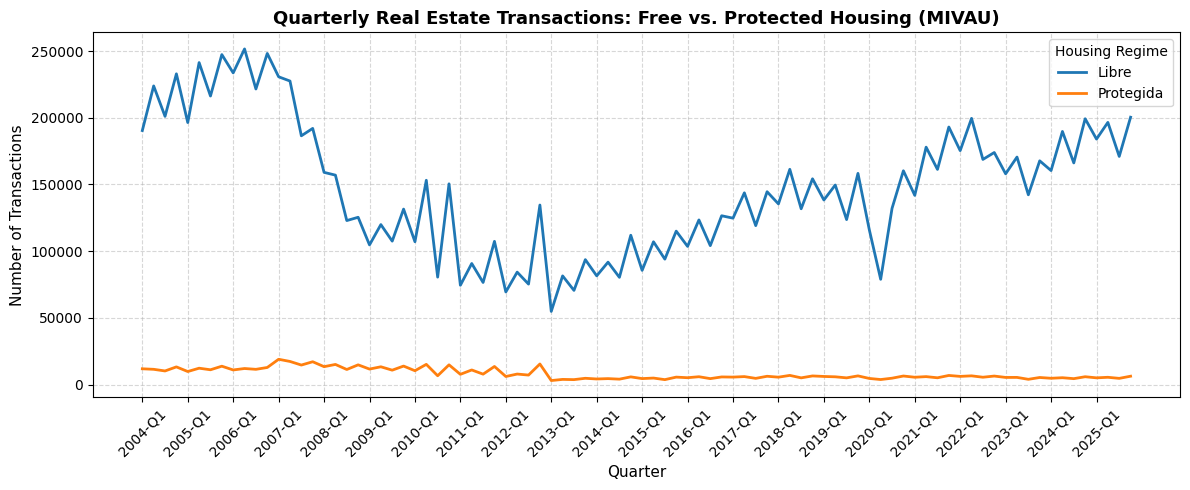

In [ ]:
query_transactions_regime = """
SELECT 
    q.YEAR,
    q.QUARTER,
    r.REGIME AS HOUSING_REGIME,
    SUM(t.TOTAL_TRANSACTIONS) AS TOTAL_TRANSACTIONS,
    SUM(t.TOTAL_TRANSACTION_PRICE) AS TOTAL_AMOUNT
FROM TRANSACTIONS t
JOIN QUARTER q ON t.QUARTER_IDQUARTER = q.IDQUARTER
JOIN REGIME r ON t.REGIME_IDREGIME = r.IDREGIME
WHERE r.REGIME != 'Sin especificar'
GROUP BY q.YEAR, q.QUARTER, r.REGIME
ORDER BY q.YEAR ASC, q.QUARTER ASC
"""

df_regime = pd.read_sql(query_transactions_regime, con=connection)

df_regime['PERIOD'] = df_regime['YEAR'].astype(str) + '-Q' + df_regime['QUARTER'].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=df_regime, 
    x='PERIOD', 
    y='TOTAL_TRANSACTIONS', 
    hue='HOUSING_REGIME',
    linewidth=2
)

plt.xticks(ticks=range(0, len(df_regime['PERIOD'].unique()), 4), labels=df_regime['PERIOD'].unique()[::4], rotation=45)

plt.title('Quarterly Real Estate Transactions: Free vs. Protected Housing (MIVAU)', fontsize=13, fontweight='bold')
plt.xlabel('Quarter', fontsize=11)
plt.ylabel('Number of Transactions', fontsize=11)
plt.legend(title='Housing Regime')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig('transactions_regime_evolution.png', dpi=300)
plt.show()

C:\Users\sergi\AppData\Local\Temp\ipykernel_17640\3070442928.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_amount = pd.read_sql(query_transactions_amount, con=connection)


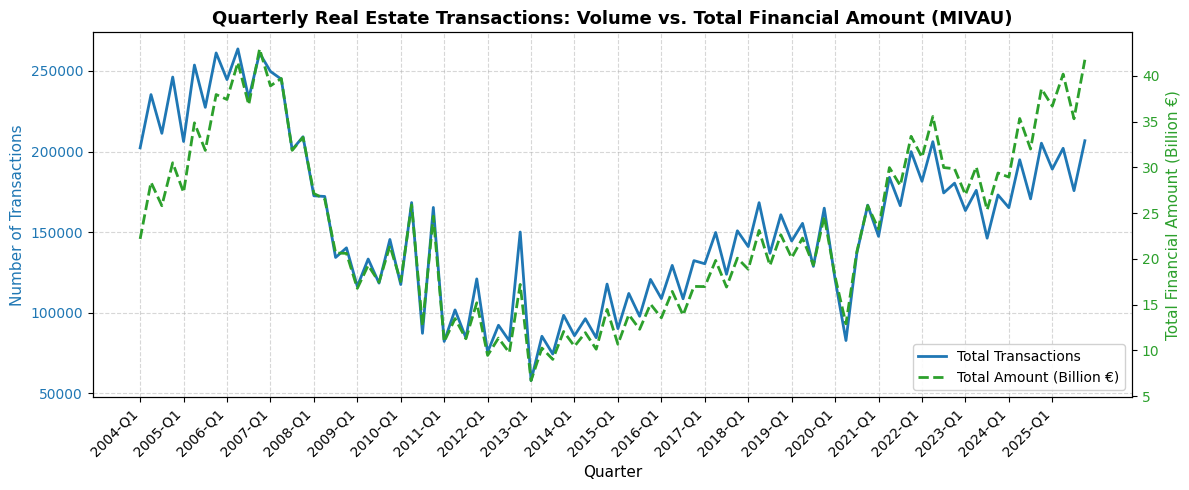

In [ ]:
query_transactions_amount = """
SELECT 
    q.YEAR,
    q.QUARTER,
    SUM(t.TOTAL_TRANSACTIONS) AS TOTAL_TRANSACTIONS,
    SUM(t.TOTAL_TRANSACTION_PRICE) AS TOTAL_AMOUNT
FROM TRANSACTIONS t
JOIN QUARTER q ON t.QUARTER_IDQUARTER = q.IDQUARTER
GROUP BY q.YEAR, q.QUARTER
ORDER BY q.YEAR ASC, q.QUARTER ASC
"""

df_amount = pd.read_sql(query_transactions_amount, con=connection)

df_amount['PERIOD'] = df_amount['YEAR'].astype(str) + '-Q' + df_amount['QUARTER'].astype(str)

df_amount['TOTAL_AMOUNT_BILLIONS'] = df_amount['TOTAL_AMOUNT'] / 1e9

fig, ax1 = plt.subplots(figsize=(12, 5))

color_trans = '#1f77b4'
ax1.set_xlabel('Quarter', fontsize=11)
ax1.set_ylabel('Number of Transactions', color=color_trans, fontsize=11)
line1 = ax1.plot(df_amount['PERIOD'], df_amount['TOTAL_TRANSACTIONS'], color=color_trans, linewidth=2, label='Total Transactions')
ax1.tick_params(axis='y', labelcolor=color_trans)

ax2 = ax1.twinx()  
color_amount = '#2ca02c'
ax2.set_ylabel('Total Financial Amount (Billion €)', color=color_amount, fontsize=11)
line2 = ax2.plot(df_amount['PERIOD'], df_amount['TOTAL_AMOUNT_BILLIONS'], color=color_amount, linewidth=2, linestyle='--', label='Total Amount (Billion €)')
ax2.tick_params(axis='y', labelcolor=color_amount)

tick_positions = range(0, len(df_amount['PERIOD']), 4)
tick_labels = df_amount['PERIOD'].iloc[::4]

ax1.set_xticks(tick_positions)
ax1.set_xticklabels(tick_labels, rotation=45, ha='right')

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', framealpha=0.9)

plt.title('Quarterly Real Estate Transactions: Volume vs. Total Financial Amount (MIVAU)', fontsize=13, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout()

plt.savefig('transactions_volume_vs_amount.png', dpi=300)
plt.show()

C:\Users\sergi\AppData\Local\Temp\ipykernel_17640\2622658356.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_appraisals = pd.read_sql(query_appraisals_total, con=connection)


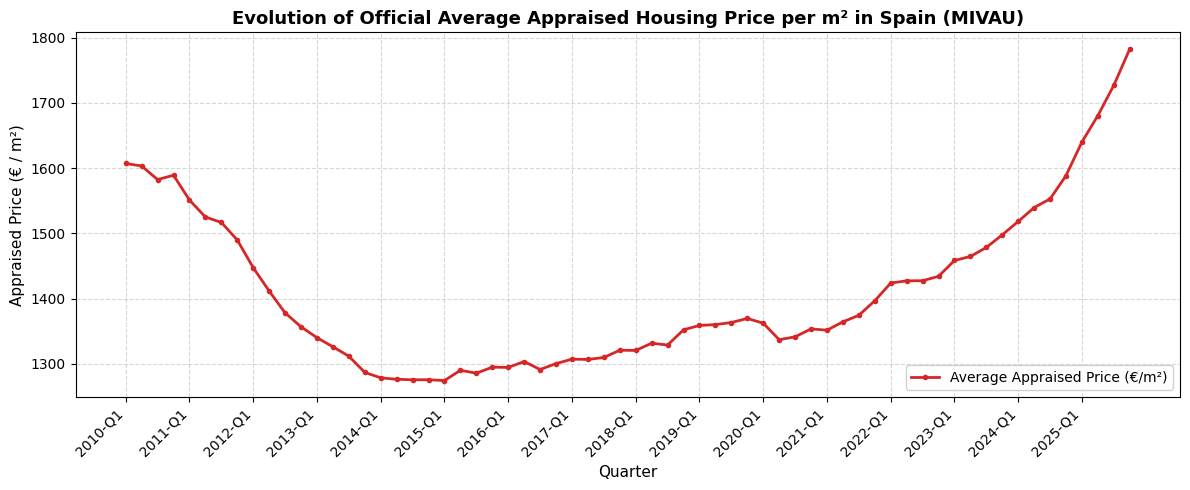

In [ ]:
query_appraisals_total = """
SELECT 
    q.year,
    q.quarter,
    AVG(a.average_appraised_price_m2) AS official_avg_price_m2
FROM appraisals a
JOIN quarter q ON a.quarter_idQuarter = q.idQuarter
JOIN location l ON a.location_idLocation = l.idLocation
WHERE UPPER(l.city) = 'TOTAL'
GROUP BY q.year, q.quarter
ORDER BY q.year ASC, q.quarter ASC
"""

df_appraisals = pd.read_sql(query_appraisals_total, con=connection)

df_appraisals.columns = [c.upper() for c in df_appraisals.columns]

df_appraisals['PERIOD'] = df_appraisals['YEAR'].astype(str) + '-Q' + df_appraisals['QUARTER'].astype(str)

plt.figure(figsize=(12, 5))
plt.plot(
    df_appraisals['PERIOD'], 
    df_appraisals['OFFICIAL_AVG_PRICE_M2'], 
    color='#d62728', 
    linewidth=2, 
    marker='o', 
    markersize=3,
    label='Average Appraised Price (€/m²)'
)

tick_positions = range(0, len(df_appraisals['PERIOD']), 4)
tick_labels = df_appraisals['PERIOD'].iloc[::4]

plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=45, ha='right')

plt.title('Evolution of Official Average Appraised Housing Price per m² in Spain (MIVAU)', fontsize=13, fontweight='bold')
plt.xlabel('Quarter', fontsize=11)
plt.ylabel('Appraised Price (€ / m²)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(loc='lower right', framealpha=0.9)
plt.tight_layout()

plt.savefig('appraisals_official_price_m2_evolution.png', dpi=300)
plt.show()

C:\Users\sergi\AppData\Local\Temp\ipykernel_17640\1637904171.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_box = pd.read_sql(query_boxplot, con=connection)
C:\Users\sergi\AppData\Local\Temp\ipykernel_17640\1637904171.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


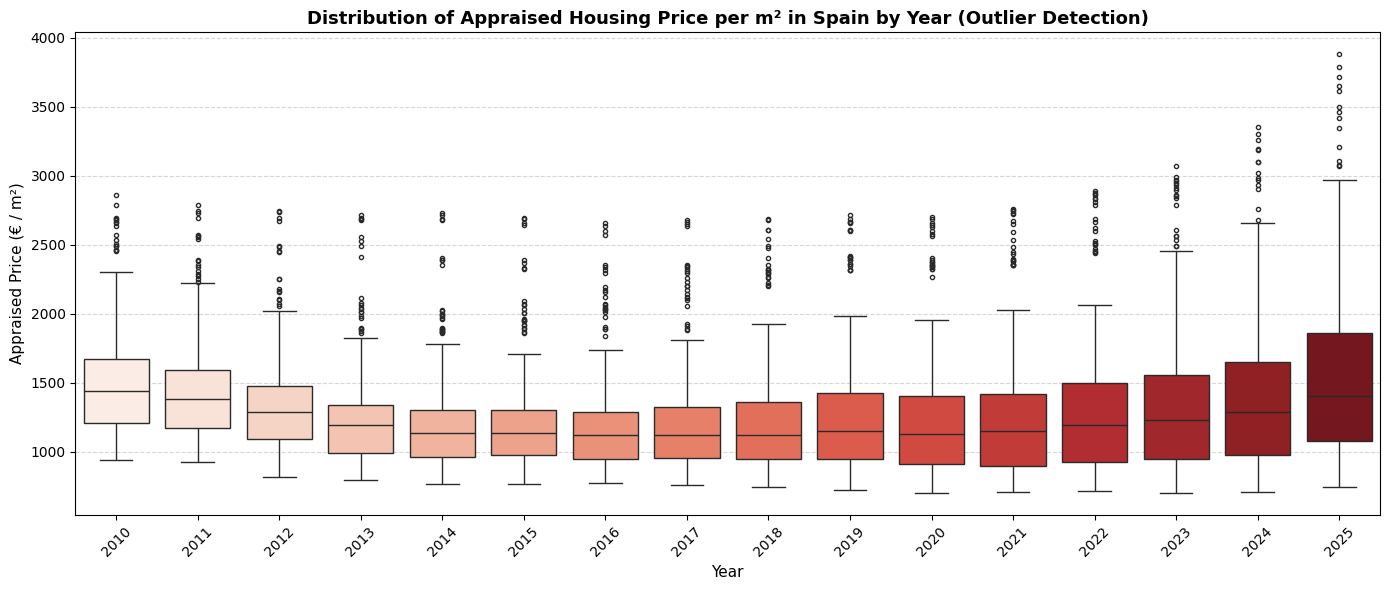

In [ ]:
import seaborn as sns

query_boxplot = """
SELECT 
    q.YEAR,
    a.AVERAGE_APPRAISED_PRICE_M2
FROM APPRAISALS a
JOIN QUARTER q ON a.QUARTER_IDQUARTER = q.IDQUARTER
JOIN LOCATION l ON a.LOCATION_IDLOCATION = l.IDLOCATION
WHERE UPPER(l.CITY) != 'TOTAL'
"""

df_box = pd.read_sql(query_boxplot, con=connection)
df_box.columns = [c.upper() for c in df_box.columns]

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_box, 
    x='YEAR', 
    y='AVERAGE_APPRAISED_PRICE_M2', 
    palette='Reds',
    fliersize=3
)

plt.title('Distribution of Appraised Housing Price per m² in Spain by Year (Outlier Detection)', fontsize=13, fontweight='bold')
plt.xlabel('Year', fontsize=11)
plt.ylabel('Appraised Price (€ / m²)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('appraisals_price_m2_boxplot.png', dpi=300)
plt.show()